# A minimal plot example

### Load Packages
We need basic packages, intake (for catalogs) and healpix 
Make sure you have the hackathon environment installed. (This may be node specific. Please check with your local host.)

In [1]:
## Standard Stuff
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib.pyplot as plt
import dask.array as da
import numcodecs

## HEALPix Specific
import healpix as hp
import easygems.healpix as egh
import easygems.remap as egr

import intake     # For catalogs
import zarr       # Data Formatting

### Load the catalog

In [2]:
catfn='/home/tmerlis/hackathon/xsh24_main.yaml'
xsh24_cat = intake.open_catalog(catfn)

# right now, have coarse and native (don't have time-independent bcs)
print(list(xsh24_cat)) 

['xsh24_coarse', 'xsh24_native']


In [3]:
zoom_select = 6
ds = xsh24_cat.xsh24_coarse(zoom=zoom_select).to_dask()
ds = ds.pipe(egh.attach_coords)

# as of may5, no coarser than level 10 zooms for the native zarr store
dsn = xsh24_cat.xsh24_native(zoom=10).to_dask()
dsn = dsn.pipe(egh.attach_coords)

/home/cs3554/.conda/envs/easy25/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),
/home/cs3554/.conda/envs/easy25/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [4]:
def worldmap(var, **kwargs):
    projection = ccrs.Robinson(central_longitude=-135.5808361)
    fig, ax = plt.subplots(
        figsize=(8, 4), subplot_kw={"projection": projection}, constrained_layout=True
    )
    ax.set_global()

    hpshow = egh.healpix_show(var, ax=ax, **kwargs)
    cbar = plt.colorbar(hpshow, ax=ax, orientation='vertical', 
                    pad=0.05, shrink=0.8)
    # fails when cartopy tries to download 
    #ax.add_feature(cf.COASTLINE, linewidth=0.8)
    #ax.add_feature(cf.BORDERS, linewidth=0.4)


In [5]:
ds

<xarray.Dataset> Size: 223GB
Dimensions:  (time: 3560, cell: 49152, plev: 31, pfull: 79)
Coordinates:
  * pfull    (pfull) float32 316B 4.514 8.301 12.45 16.74 ... 989.5 994.3 998.3
  * plev     (plev) float32 124B 1.0 2.0 3.0 5.0 7.0 ... 925.0 950.0 975.0 1e+03
  * time     (time) object 28kB 2019-10-20 03:00:00 ... 2021-01-07 00:00:00
    crs      int64 8B 0
  * cell     (cell) int64 393kB 2 6 10 14 18 ... 196594 196598 196602 196606
    lat      (cell) float64 393kB 1.194 2.388 2.388 3.583 ... nan nan nan nan
    lon      (cell) float64 393kB 44.3 45.7 42.89 44.3 ... 135.0 135.0 135.0
Data variables: (12/31)
    clivi    (time, cell) float32 700MB ...
    clt      (time, cell) float32 700MB ...
    clwvi    (time, cell) float32 700MB ...
    hflsd    (time, cell) float32 700MB ...
    hfssd    (time, cell) float32 700MB ...
    hur      (time, plev, cell) float32 22GB ...
    ...       ...
    uas      (time, cell) float32 700MB ...
    va       (time, plev, cell) float32 22GB ...
    vas      (time, cell) float32 700MB ...
    wa       (time, plev, cell) float32 22GB ...
    wap      (time, plev, cell) float32 22GB ...
    zg       (time, plev, cell) float32 22GB ...

CPU times: user 2.6 s, sys: 428 ms, total: 3.03 s
Wall time: 1.71 s


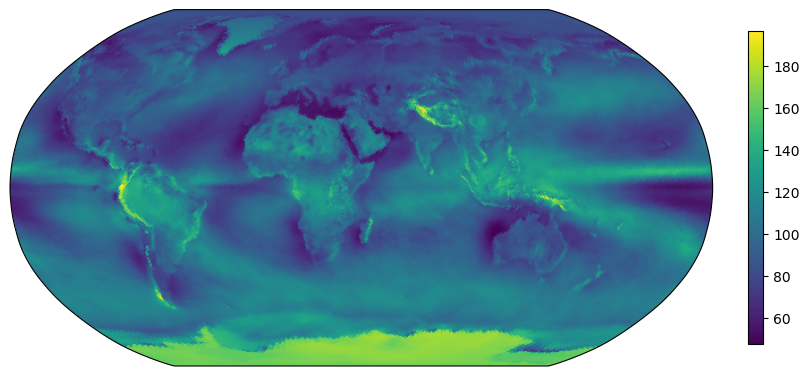

In [6]:
%%time

worldmap(ds.rsut.mean(dim='time'))
